# **10 - Robust model selection and median-aligned loss**

This notebook implements the amended selection protocol of `CLAUDE.md` (rule 8) and answers the review findings F-01, F-02, F-03, F-04 and F-06.

**Protocol.**
- Candidates are compared on two rolling-origin pseudo-tests: fit on rows before 2023-01-01 and test on 2023; fit on rows before 2024-01-01 and test on 2024. **No 2025 row is used to choose among candidates**; 2025 is only reported for the selected models.
- The one-standard-error rule uses the most conservative of three standard errors of the paired WAPE difference to the leader: row bootstrap, month-block bootstrap and district-block bootstrap. Ties go to the model with fewer parameters, then to the smaller absolute aggregate bias.
- Extrapolation is **behavioural**: a model extrapolates if the annual means of its projected path (a fixed profile, 2026-2028) are not constant (relative change above 0.001); otherwise it is labelled "level persistence".
- Median-aligned loss: every boosting model gets a `_median` variant (`loss='quantile'`, `quantile=0.5` on `log1p(target)`), because WAPE is minimized by a median and not by a geometric mean.

**Limitation of this iteration.** The hyperparameters are those saved by the earlier notebooks for the base model (the median variants reuse them). They were tuned with CV folds that include 2023 and 2024, so the pseudo-test windows are not fully independent of the settings; tuning inside each fit window is left for a later step. 2025 was inspected in earlier iterations of this project; the 2025 figures are therefore not those of a fully untouched hold-out.

| block | question |
|---|---|
| a | Do the row, month-block and district-block bootstraps agree? |
| b | Which candidates win on the pseudo-tests, and which of them extrapolate? |
| c | Is the underprediction persistent across years or specific to 2025? |
| d | How much does rescaling change the error? (global factor estimated on the pseudo-tests only) |
| e | Is the log target skewed enough to justify the median loss? |

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rent_model import config
from rent_model.compare import classify_projection, complexity_of, extrapolation_kind
from rent_model.data import load_clean
from rent_model.features import build_features, build_target, select_track
from rent_model.io import save_run
from rent_model.metrics import (all_metrics, block_bootstrap_wape_diff, paired_bootstrap_wape_diff, wape)
from rent_model.projection import FUTURE
from rent_model.pseudotest import WINDOWS, check_windows, duan_factor, pool, run_windows, select, smeared_prediction, window_split
from rent_model.recipes import ModelRecipe, projected_path, recipe_ids
from rent_model.splits import temporal_split

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 100
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Data, windows and candidates

In [2]:
df = load_clean()
CANDIDATES = recipe_ids()
MEDIAN_IDS = [m for m in CANDIDATES if m.endswith('_median')]
check_windows()
data = {}
for track, spec in config.TRACKS.items():
    df_t = select_track(df, track)
    train, test = temporal_split(df_t)
    data[track] = dict(df=df_t, train=train, test=test, target=spec['target'])
    sizes = []
    for w in WINDOWS:
        tr, te = window_split(df_t, w)
        sizes.append(f"fit < {w['fit_end']:%Y-%m-%d}: {len(tr):,} rows, test {w['test_year']}: {len(te):,} rows")
    print(f"{track}: " + ' | '.join(sizes) + f" | final TRAIN {len(train):,} rows, TEST 2025 {len(test):,} rows")

def features(track):
    return lambda frame: build_features(frame, track, include_time=True, include_legal_dong=True)

print(f'{len(CANDIDATES)} candidates per track:', CANDIDATES)

jeonse: fit < 2023-01-01: 50,327 rows, test 2023: 47,513 rows | fit < 2024-01-01: 97,840 rows, test 2024: 41,008 rows | final TRAIN 138,848 rows, TEST 2025 37,935 rows
wolse: fit < 2023-01-01: 50,860 rows, test 2023: 51,322 rows | fit < 2024-01-01: 102,182 rows, test 2024: 50,532 rows | final TRAIN 152,714 rows, TEST 2025 57,829 rows
16 candidates per track: ['baseline_district_type_area', 'ridge_static', 'ridge_time', 'ridge_time_rich', 'rf_detrended', 'hgb_static', 'hgb_time', 'hgb_detrended', 'hgb_legal_dong', 'hybrid_ridge', 'hybrid_hgb', 'hgb_static_median', 'hgb_time_median', 'hgb_detrended_median', 'hgb_legal_dong_median', 'hybrid_hgb_median']


## a) Row vs month-block vs district-block bootstrap

In [3]:
def saved_predictions(track, model_id):
    return pd.read_parquet(config.PREDICTIONS_DIR / f'{track}__{model_id}.parquet')['y_pred'].to_numpy()

rows = []
for track, (a, b) in {'jeonse': ('hybrid_hgb', 'hgb_detrended'), 'wolse': ('hgb_detrended', 'hybrid_hgb')}.items():
    test = data[track]['test']; y = test[data[track]['target']].to_numpy()
    pa, pb = saved_predictions(track, a), saved_predictions(track, b)
    for name, res in [('row', paired_bootstrap_wape_diff(y, pa, pb)),
                      ('month block', block_bootstrap_wape_diff(y, pa, pb, test['contract_month'])),
                      ('district block', block_bootstrap_wape_diff(y, pa, pb, test['district_name']))]:
        rows.append({'track': track, 'comparison': f'WAPE({a}) - WAPE({b})', 'resampling': name, 'wape_diff_pts': res['diff'],
                     'se': res['se'], 'ci_low': res['ci_low'], 'ci_high': res['ci_high'],
                     'interval_includes_zero': bool(res['ci_low'] <= 0 <= res['ci_high'])})
    print(f"{track}: {test['contract_month'].nunique()} month blocks, {test['district_name'].nunique()} district blocks, {len(test):,} rows")
display(pd.DataFrame(rows).set_index(['track', 'comparison', 'resampling']))
print('Illustration of the resampling schemes on the saved 2025 predictions; it is not used to choose a model.')

jeonse: 12 month blocks, 25 district blocks, 37,935 rows


wolse: 12 month blocks, 25 district blocks, 57,829 rows


wape_diff_pts     se  ci_low  ci_high  interval_includes_zero
track  comparison                             resampling                                                                   
jeonse WAPE(hybrid_hgb) - WAPE(hgb_detrended) row                   -0.2034 0.0590 -0.3205  -0.0835                   False
                                              month block           -0.2034 0.2188 -0.6072   0.2329                    True
                                              district block        -0.2034 0.1277 -0.4683   0.0256                    True
wolse  WAPE(hgb_detrended) - WAPE(hybrid_hgb) row                   -0.8063 0.0199 -0.8436  -0.7657                   False
                                              month block           -0.8063 0.0534 -0.9137  -0.7022                   False
                                              district block        -0.8063 0.0512 -0.9099  -0.7151                   False

Illustration of the resampling schemes on the saved 2025 predictions; it is not used to choose a model.


**Interpretation.** The row bootstrap overstates how decisive a one-year difference is. For the Jeonse comparison, WAPE(`hybrid_hgb`) minus WAPE(`hgb_detrended`) is -0.2034 points on the 2025 predictions. Resampling rows gives a standard error of 0.0590 and an interval of -0.3205 to -0.0835, which excludes zero; resampling the 12 months gives a standard error of 0.2188 and an interval of -0.6072 to 0.2329, and resampling the 25 districts gives 0.1277 and -0.4683 to 0.0256; both include zero. The Wolse difference of -0.8063 points is robust: the standard errors are 0.0199 (rows), 0.0534 (months) and 0.0512 (districts) and the widest interval is -0.9137 to -0.7022, still below zero. Contracts of the same month or district are correlated, so a small difference can look decisive with rows and be a tie with blocks. The selection below uses the largest of the three standard errors.

## b) Pseudo-tests 2023 and 2024

In [4]:
pseudo = {track: {} for track in config.TRACKS}
for track in config.TRACKS:
    for model_id in CANDIDATES:
        pseudo[track][model_id] = run_windows(ModelRecipe(model_id, track), data[track]['df'], features(track))

pooled_table = {}
for track in config.TRACKS:
    rows = []
    for model_id in CANDIDATES:
        res = pseudo[track][model_id]
        y, preds, _, _ = pool({model_id: res})
        rows.append({'model_id': model_id, 'wape_2023': res['2023']['metrics']['wape_pct'], 'wape_2024': res['2024']['metrics']['wape_pct'],
                     'wape_pooled': wape(y, preds[model_id]), 'agg_bias_2023': res['2023']['metrics']['aggregate_bias_pct'],
                     'agg_bias_2024': res['2024']['metrics']['aggregate_bias_pct']})
    pooled_table[track] = pd.DataFrame(rows).set_index('model_id').sort_values('wape_pooled')
    print(f'{track}: pseudo-test results (WAPE %, aggregate bias %), sorted by the pooled WAPE of the two windows')
    display(pooled_table[track])

jeonse: pseudo-test results (WAPE %, aggregate bias %), sorted by the pooled WAPE of the two windows


,wape_2023,wape_2024,wape_pooled,agg_bias_2023,agg_bias_2024
model_id,,,,,
hgb_legal_dong,16.6457,16.1043,16.3843,4.8101,-8.3346
hgb_legal_dong_median,17.1561,16.0072,16.6014,6.1733,-7.9769
hgb_time_median,17.3273,17.3456,17.3361,-1.5373,-4.2469
hgb_time,17.8333,17.6726,17.7557,-2.8507,-5.2603
hybrid_hgb,18.0254,17.8245,17.9284,-0.2785,-6.3972
hybrid_hgb_median,18.3011,17.5636,17.9451,1.7449,-5.6518
hgb_detrended,19.4546,17.1627,18.3481,7.5624,0.8066
rf_detrended,19.4380,17.5558,18.5293,6.2773,0.1734
hgb_static,18.5591,18.5758,18.5672,3.8650,-8.6851


wolse: pseudo-test results (WAPE %, aggregate bias %), sorted by the pooled WAPE of the two windows


,wape_2023,wape_2024,wape_pooled,agg_bias_2023,agg_bias_2024
model_id,,,,,
hgb_legal_dong_median,37.7919,41.7349,39.7454,-6.2621,-3.7336
hgb_detrended_median,37.6106,42.7934,40.1784,-4.7512,1.6131
hgb_static_median,37.8595,42.9401,40.3767,-7.9088,-4.1413
hgb_time_median,38.2498,43.2210,40.7128,-7.6039,-0.9812
hybrid_hgb_median,38.5561,42.9303,40.7233,-11.9356,-4.6066
hgb_legal_dong,39.6897,43.3239,41.4902,-15.6548,-15.7420
hgb_detrended,39.4363,43.7562,41.5765,-14.6353,-11.0657
hgb_static,40.0895,44.6650,42.3564,-17.3512,-16.1009
hgb_time,40.1778,44.6125,42.3750,-17.3377,-15.4545


**Interpretation.** On the pseudo-tests (WAPE pooled over 2023 and 2024) the Jeonse leader is `hgb_legal_dong` with 16.3843%, followed by its median-loss variant (16.6014%), `hgb_time_median` (17.3361%), `hgb_time` (17.7557%), `hybrid_hgb` (17.9284%), `hybrid_hgb_median` (17.9451%), `hgb_detrended` (18.3481%) and `rf_detrended` (18.5293%); the ridge models are between 22.8101% and 24.1086% and the district x type x area baseline has 26.3620%. In Jeonse the median loss is not systematically better: it improves `hgb_time` (17.7557% to 17.3361%) and leaves `hybrid_hgb` almost unchanged (17.9284% to 17.9451%), and it is worse for `hgb_legal_dong` (16.3843% to 16.6014%), `hgb_static` (18.5672% to 18.8102%) and `hgb_detrended` (18.3481% to 18.8942%). In Wolse the five median-loss variants occupy the first five places (`hgb_legal_dong_median` 39.7454%, `hgb_detrended_median` 40.1784%, `hgb_static_median` 40.3767%, `hgb_time_median` 40.7128%, `hybrid_hgb_median` 40.7233%), ahead of the best squared-loss model (`hgb_legal_dong`, 41.4902%), the baseline (45.4250%) and the linear models (46.1585% to 48.4557%). The aggregate bias of the Wolse squared-loss models is about -15% in both windows (`hgb_legal_dong`: -15.6548% in 2023 and -15.7420% in 2024), against -6.2621% and -3.7336% for `hgb_legal_dong_median`.

### Full-TRAIN fits: behavioural extrapolation check and 2025 predictions

In [5]:
full, test_pred, behaviour, annual = {}, {}, {}, {}
for track in config.TRACKS:
    d = data[track]; X_test = features(track)(d['test'])
    for model_id in CANDIDATES:
        recipe = ModelRecipe(model_id, track).fit(d['train'], config.TEST_START)
        full[(track, model_id)] = recipe
        test_pred[(track, model_id)] = recipe.predict(X_test, d['test']['contract_month'])
        path = projected_path(recipe, d['df'], FUTURE)
        behaviour[(track, model_id)] = classify_projection(path)
        annual[(track, model_id)] = path.groupby(path.index.year).mean()

# the recipes reproduce the runs saved by the earlier notebooks (same data, same settings)
worst = 0.0
for (track, model_id), pred in test_pred.items():
    if not model_id.endswith('_median'):
        worst = max(worst, float(np.max(np.abs(pred - saved_predictions(track, model_id)))))
print(f'max absolute difference between the recipe predictions and the saved 2025 runs of the base models: {worst:.3e}')
assert worst < 1e-6

rows = [{'track': t, 'model_id': m, 'label (previous criterion)': extrapolation_kind(m)[0], 'behaviour (current criterion)': behaviour[(t, m)],
         'annual mean 2026': annual[(t, m)].iloc[0], 'annual mean 2027': annual[(t, m)].iloc[1], 'annual mean 2028': annual[(t, m)].iloc[2],
         'change 2028 vs 2026 (%)': (annual[(t, m)].iloc[2] / annual[(t, m)].iloc[0] - 1) * 100} for t, m in full]
behaviour_table = pd.DataFrame(rows).set_index(['track', 'model_id'])
print('Fixed profile: Apartment of 60 m2 in Mapo-gu; annual mean of the projected monthly value (10,000 KRW); change above 0.1% = extrapolates')
for track in config.TRACKS:
    display(behaviour_table.loc[track])

max absolute difference between the recipe predictions and the saved 2025 runs of the base models: 6.403e-10
Fixed profile: Apartment of 60 m2 in Mapo-gu; annual mean of the projected monthly value (10,000 KRW); change above 0.1% = extrapolates


,label (previous criterion),behaviour (current criterion),annual mean 2026,annual mean 2027,annual mean 2028,change 2028 vs 2026 (%)
model_id,,,,,,
baseline_district_type_area,none,level persistence,"60,190.0000","60,190.0000","60,190.0000",0.0000
ridge_static,none,level persistence,"45,967.7226","45,967.7226","45,967.7226",0.0000
ridge_time,linear time feature,extrapolates,"46,634.0260","46,859.5602","47,086.1851",0.9696
ridge_time_rich,linear time feature,extrapolates,"44,870.4239","45,076.5615","45,283.6462",0.9209
rf_detrended,log-linear trend (detrended),extrapolates,"63,957.6800","68,590.9106","73,559.7770",15.0132
hgb_static,none,level persistence,"51,809.8468","51,809.8468","51,809.8468",0.0000
hgb_time,tree time feature (cannot extrapolate),level persistence,"61,082.9843","61,082.9843","61,082.9843",0.0000
hgb_detrended,log-linear trend (detrended),extrapolates,"64,150.1263","68,797.2978","73,781.1151",15.0132
hgb_legal_dong,none,level persistence,"41,267.0087","41,267.0087","41,267.0087",0.0000


,label (previous criterion),behaviour (current criterion),annual mean 2026,annual mean 2027,annual mean 2028,change 2028 vs 2026 (%)
model_id,,,,,,
baseline_district_type_area,none,level persistence,150.0000,150.0000,150.0000,0.0000
ridge_static,none,level persistence,87.4588,87.4588,87.4588,0.0000
ridge_time,linear time feature,extrapolates,79.2381,76.6347,74.1158,-6.4644
ridge_time_rich,linear time feature,extrapolates,84.1710,82.0592,79.9998,-4.9556
rf_detrended,log-linear trend (detrended),extrapolates,82.6392,83.0343,83.4314,0.9586
hgb_static,none,level persistence,89.2156,89.2156,89.2156,0.0000
hgb_time,tree time feature (cannot extrapolate),level persistence,93.6604,93.6604,93.6604,0.0000
hgb_detrended,log-linear trend (detrended),extrapolates,83.2338,83.6318,84.0316,0.9585
hgb_legal_dong,none,level persistence,48.9199,48.9199,48.9199,0.0000


**Interpretation.** The behavioural criterion differs from the previous label. The Jeonse hybrids use the naive index forecast, so their projected path is constant (`hybrid_hgb` has the same annual mean, 55,800.9586, in 2026, 2027 and 2028; change 0.0000%) and they are "level persistence" even though their label is "forecasted index". In Wolse the drift index forecast moves the path (`hybrid_hgb` -3.5713%, `hybrid_hgb_median` -3.5615%, `hybrid_ridge` -3.5685% from 2026 to 2028) and they extrapolate. The detrended models add back the log-linear trend fit on TRAIN: the 2028 annual mean is 15.0132% above that of 2026 in Jeonse (`hgb_detrended`, `rf_detrended` and `hgb_detrended_median`) and between 0.9553% and 0.9586% above in Wolse. The linear time models change by 0.9696% (`ridge_time`) and 0.9209% (`ridge_time_rich`) in Jeonse and by -6.4644% and -4.9556% in Wolse. Static models and the tree models with a time feature are constant (0.0000%). The annual means are not comparable across models as price levels (they depend on the features each model uses; for example Jeonse `hgb_legal_dong` 41,267.0087 against `hgb_static` 51,809.8468); only the change across years is used. For this profile the median-loss projections are higher than the squared-loss ones in Wolse (`hgb_static_median` 124.6038 against `hgb_static` 89.2156).

### Selection on the pseudo-tests only

In [6]:
selection = {}
for track in config.TRACKS:
    ext_ids = [m for m in CANDIDATES if behaviour[(track, m)] == 'extrapolates']
    table_u, leader_u, chosen_u = select(pseudo[track], n_boot=1000)
    table_e, leader_e, chosen_e = select(pseudo[track], n_boot=1000, only=ext_ids)
    selection[track] = dict(table_all=table_u, leader=leader_u, unconstrained=chosen_u, table_ext=table_e, ext_leader=leader_e, extrapolating=chosen_e, ext_ids=ext_ids)
    cols = ['model_id', 'wape_pct', 'diff_vs_leader', 'se_diff', 'se_source', 'tie_with_leader', 'complexity', 'abs_aggregate_bias']
    print(f"{track}: all candidates -> leader {leader_u}; one-SE tie set {list(table_u[table_u['tie_with_leader']]['model_id'])}; selected (fewest parameters, then smallest bias) = {chosen_u}")
    display(table_u[cols].head(8))
    print(f"{track}: candidates that extrapolate {ext_ids} -> leader {leader_e}; tie set {list(table_e[table_e['tie_with_leader']]['model_id'])}; selected = {chosen_e}")
    display(table_e[cols].head(6))

# no 2025 row reaches the selection tables: every row of every pseudo-test result is dated before the TEST year
latest = max(pd.DatetimeIndex(r['months']).max() for track in config.TRACKS for res in pseudo[track].values() for r in res.values())
assert latest < config.TEST_START
print(f'assertion passed: the latest row used by the selection tables is dated {latest:%Y-%m-%d}, before the TEST year starts ({config.TEST_START:%Y-%m-%d})')

jeonse: all candidates -> leader hgb_legal_dong; one-SE tie set ['hgb_legal_dong']; selected (fewest parameters, then smallest bias) = hgb_legal_dong


,model_id,wape_pct,diff_vs_leader,se_diff,se_source,tie_with_leader,complexity,abs_aggregate_bias
0,hgb_legal_dong,16.3843,0.0000,0.0000,row,True,13,1.5361
1,hgb_legal_dong_median,16.6014,0.2171,0.0840,district,False,13,0.6583
2,hgb_time_median,17.3361,0.9518,0.3491,district,False,12,2.8455
3,hgb_time,17.7557,1.3714,0.3461,district,False,12,4.0140
4,hybrid_hgb,17.9284,1.5441,0.2799,district,False,14,3.2325
5,hybrid_hgb_median,17.9451,1.5607,0.3004,district,False,14,1.8262
6,hgb_detrended,18.3481,1.9637,0.3300,district,False,13,4.3008
7,rf_detrended,18.5293,2.1450,0.2219,district,False,11,3.3303


jeonse: candidates that extrapolate ['ridge_time', 'ridge_time_rich', 'rf_detrended', 'hgb_detrended', 'hgb_detrended_median'] -> leader hgb_detrended; tie set ['hgb_detrended', 'rf_detrended']; selected = rf_detrended


,model_id,wape_pct,diff_vs_leader,se_diff,se_source,tie_with_leader,complexity,abs_aggregate_bias
0,hgb_detrended,18.3481,0.0000,0.0000,row,True,13,4.3008
1,rf_detrended,18.5293,0.1812,0.2842,district,True,11,3.3303
2,hgb_detrended_median,18.8942,0.5461,0.1103,month,False,13,5.4282
3,ridge_time_rich,23.2944,4.9463,0.7149,month,False,8,9.9243
4,ridge_time,24.1086,5.7605,0.7431,month,False,7,10.9539


wolse: all candidates -> leader hgb_legal_dong_median; one-SE tie set ['hgb_legal_dong_median']; selected (fewest parameters, then smallest bias) = hgb_legal_dong_median


,model_id,wape_pct,diff_vs_leader,se_diff,se_source,tie_with_leader,complexity,abs_aggregate_bias
0,hgb_legal_dong_median,39.7454,0.0000,0.0000,row,True,13,5.0094
1,hgb_detrended_median,40.1784,0.4330,0.1643,district,False,13,1.5980
2,hgb_static_median,40.3767,0.6313,0.1779,district,False,12,6.0422
3,hgb_time_median,40.7128,0.9673,0.1913,district,False,12,4.3227
4,hybrid_hgb_median,40.7233,0.9779,0.1726,district,False,14,8.3044
5,hgb_legal_dong,41.4902,1.7448,0.1278,district,False,13,15.6980
6,hgb_detrended,41.5765,1.8311,0.1789,district,False,13,12.8668
7,hgb_static,42.3564,2.6110,0.1911,district,False,12,16.7317


wolse: candidates that extrapolate ['ridge_time', 'ridge_time_rich', 'rf_detrended', 'hgb_detrended', 'hybrid_ridge', 'hybrid_hgb', 'hgb_detrended_median', 'hybrid_hgb_median'] -> leader hgb_detrended_median; tie set ['hgb_detrended_median']; selected = hgb_detrended_median


,model_id,wape_pct,diff_vs_leader,se_diff,se_source,tie_with_leader,complexity,abs_aggregate_bias
0,hgb_detrended_median,40.1784,0.0000,0.0000,row,True,13,1.5980
1,hybrid_hgb_median,40.7233,0.5449,0.1083,month,False,14,8.3044
2,hgb_detrended,41.5765,1.3982,0.1135,month,False,13,12.8668
3,rf_detrended,42.4400,2.2616,0.2434,district,False,11,13.5209
4,hybrid_hgb,42.9482,2.7698,0.2016,month,False,14,18.7735
5,ridge_time_rich,46.1585,5.9801,0.3389,district,False,8,20.6486


assertion passed: the latest row used by the selection tables is dated 2024-12-01, before the TEST year starts (2025-01-01)


**Interpretation.** Jeonse, all candidates: `hgb_legal_dong` leads and is the only member of the one-standard-error tie set; the closest model, `hgb_legal_dong_median`, is 0.2171 points behind with a conservative standard error of 0.0840 (district blocks), which is not a tie. Among the models whose projection extrapolates, `hgb_detrended` leads (18.3481%) and `rf_detrended` is a tie (difference 0.1812 points against a standard error of 0.2842, district blocks); the tie goes to the model with fewer parameters, `rf_detrended` (complexity 11 against 13). `hybrid_hgb` is not eligible because its projection is level persistence. `hgb_detrended_median` is 0.5461 points behind (standard error 0.1103, month blocks) and is not a tie. Wolse, all candidates: `hgb_legal_dong_median` leads (39.7454%) with no tie (the nearest, `hgb_detrended_median`, is 0.4330 points behind with a standard error of 0.1643); among the models that extrapolate `hgb_detrended_median` leads (40.1784%) and the nearest, `hybrid_hgb_median`, is 0.5449 points behind (standard error 0.1083, month blocks), so it is chosen. In most rows the largest standard error comes from the district blocks (see `se_source`). The assertion passed: the latest row used by the selection tables is dated 2024-12-01, before the TEST year starts.

### 2025: evaluation of the selected models (reported once)

In [7]:
def run_2025(track, model_id):
    test = data[track]['test']
    return all_metrics(test[data[track]['target']].to_numpy(), test_pred[(track, model_id)])

previous = {'jeonse': {'unconstrained': 'hgb_legal_dong', 'extrapolating': 'hybrid_hgb'},
            'wolse': {'unconstrained': 'hgb_legal_dong', 'extrapolating': 'hgb_detrended'}}
rows = []
for track in config.TRACKS:
    for kind in ['unconstrained', 'extrapolating']:
        old, new = previous[track][kind], selection[track][kind]
        for label, mid in [('previous protocol (2025-based)', old), ('amended protocol (pseudo-tests)', new)]:
            m = run_2025(track, mid) if (track, mid) in test_pred else None
            rows.append({'track': track, 'selection': kind, 'protocol': label, 'model_id': mid,
                         'wape_2025': m['wape_pct'] if m else np.nan, 'median_bias_2025': m['median_bias_pct'] if m else np.nan,
                         'aggregate_bias_2025': m['aggregate_bias_pct'] if m else np.nan})
winners = pd.DataFrame(rows).set_index(['track', 'selection', 'protocol'])
display(winners)



model_id  wape_2025  median_bias_2025  aggregate_bias_2025
track  selection     protocol                                                                                                
jeonse unconstrained previous protocol (2025-based)          hgb_legal_dong    15.8354           -7.3684              -8.5658
                     amended protocol (pseudo-tests)         hgb_legal_dong    15.8354           -7.3684              -8.5658
       extrapolating previous protocol (2025-based)              hybrid_hgb    17.4448           -3.3505              -5.0263
                     amended protocol (pseudo-tests)           rf_detrended    17.9091            5.2498               2.7507
wolse  unconstrained previous protocol (2025-based)          hgb_legal_dong    44.3335          -16.9086             -21.6673
                     amended protocol (pseudo-tests)  hgb_legal_dong_median    41.3097           -6.4869              -9.5688
       extrapolating previous protocol (2025-based)           hgb_detrended    45.3293          -16.9244             -22.4758
                     amended protocol (pseudo-tests)   hgb_detrended_median    42.4780           -6.1016             -10.2318

**Interpretation.** Under the amended protocol the Jeonse unconstrained choice does not change (`hgb_legal_dong`, 2025 WAPE 15.8354%), the Jeonse extrapolating choice changes from `hybrid_hgb` (17.4448%, median bias -3.3505%, aggregate bias -5.0263%) to `rf_detrended` (17.9091%, +5.2498%, +2.7507%), and both Wolse choices change to median-loss variants: the unconstrained choice from `hgb_legal_dong` (44.3335%, median bias -16.9086%, aggregate -21.6673%) to `hgb_legal_dong_median` (41.3097%, -6.4869%, -9.5688%) and the extrapolating choice from `hgb_detrended` (45.3293%, -16.9244%, -22.4758%) to `hgb_detrended_median` (42.4780%, -6.1016%, -10.2318%). The 2025 values are reported after the choice and did not influence it; the new Jeonse extrapolating model is worse on 2025 than the previous one (17.9091% against 17.4448%), which is a consequence of the protocol and not evidence against it. The ten new median-loss runs and the two pseudo-test reports are saved at the end of the notebook.

## c) Aggregate bias by year: persistent or specific to 2025?

agg_bias_2023  agg_bias_2024  agg_bias_2025  median_bias_2023  median_bias_2024  median_bias_2025
track  model_id                                                                                                                
jeonse hybrid_hgb                   -0.2785        -6.3972        -5.0263           -0.5610           -4.7248           -3.3505
       rf_detrended                  6.2773         0.1734         2.7507            7.1632            2.4310            5.2498
       hgb_legal_dong                4.8101        -8.3346        -8.5658            4.2072           -7.1310           -7.3684
       hgb_legal_dong_median         6.1733        -7.9769        -7.7001            5.4860           -6.5793           -6.3648
       hgb_detrended_median          9.6918         0.8606         4.2619            9.0822            2.9034            6.2381
wolse  hgb_detrended               -14.6353       -11.0657       -22.4758           -9.2893           -6.3314          -16.9244
       hgb_detrended_median         -4.7512         1.6131       -10.2318           -0.7912            4.0756           -6.1016
       hgb_legal_dong_median        -6.2621        -3.7336        -9.5688           -3.6348           -2.2235           -6.4869
       hgb_legal_dong              -15.6548       -15.7420       -21.6673          -11.1221          -11.5038          -16.9086

wape_2023  wape_2024  wape_2025
track  model_id                                              
jeonse hybrid_hgb               18.0254    17.8245    17.4448
       rf_detrended             19.4380    17.5558    17.9091
       hgb_legal_dong           16.6457    16.1043    15.8354
       hgb_legal_dong_median    17.1561    16.0072    15.5379
       hgb_detrended_median     20.4090    17.2714    17.7049
wolse  hgb_detrended            39.4363    43.7562    45.3293
       hgb_detrended_median     37.6106    42.7934    42.4780
       hgb_legal_dong_median    37.7919    41.7349    41.3097
       hgb_legal_dong           39.6897    43.3239    44.3335

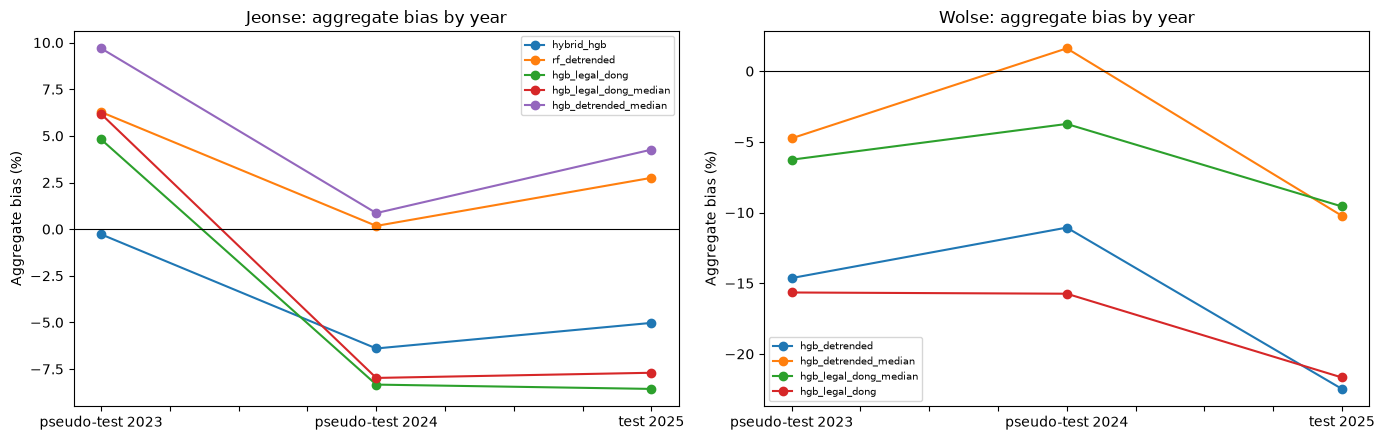

In [8]:
def yearly_row(track, model_id):
    out = {'track': track, 'model_id': model_id}
    for w in ('2023', '2024'):
        m = pseudo[track][model_id][w]['metrics']
        out.update({f'agg_bias_{w}': m['aggregate_bias_pct'], f'median_bias_{w}': m['median_bias_pct'], f'wape_{w}': m['wape_pct']})
    m = run_2025(track, model_id)
    out.update({'agg_bias_2025': m['aggregate_bias_pct'], 'median_bias_2025': m['median_bias_pct'], 'wape_2025': m['wape_pct']})
    return out

focus = {t: list(dict.fromkeys([previous[t]['extrapolating'], selection[t]['extrapolating'], selection[t]['unconstrained'],
                                'hgb_legal_dong', 'hgb_legal_dong_median', 'hgb_detrended_median'])) for t in config.TRACKS}
bias_by_year = pd.DataFrame([yearly_row(t, m) for t in config.TRACKS for m in focus[t]]).set_index(['track', 'model_id'])
display(bias_by_year[['agg_bias_2023', 'agg_bias_2024', 'agg_bias_2025', 'median_bias_2023', 'median_bias_2024', 'median_bias_2025']])
display(bias_by_year[['wape_2023', 'wape_2024', 'wape_2025']])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, track in zip(axes, config.TRACKS):
    sub = bias_by_year.loc[track][['agg_bias_2023', 'agg_bias_2024', 'agg_bias_2025']]
    sub.columns = ['pseudo-test 2023', 'pseudo-test 2024', 'test 2025']
    sub.T.plot(ax=ax, marker='o')
    ax.axhline(0, color='black', lw=0.8); ax.set_ylabel('Aggregate bias (%)'); ax.set_title(f'{track.capitalize()}: aggregate bias by year'); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / '10_bias_by_year.png', dpi=130); plt.show()

**Interpretation.** The underprediction is persistent in Wolse and only partly persistent in Jeonse. Wolse, squared loss: the aggregate bias of `hgb_legal_dong` is -15.6548% in 2023, -15.7420% in 2024 and -21.6673% in 2025, and that of `hgb_detrended` is -14.6353%, -11.0657% and -22.4758%: it is present in both pseudo-test windows, which never saw 2025, and 2025 is lower still. With the median loss the bias is smaller in the pseudo-tests (`hgb_legal_dong_median` -6.2621% and -3.7336%) but 2025 is again lower (-9.5688%); `hgb_detrended_median` goes from +1.6131% in 2024 to -10.2318% in 2025. Jeonse: `hgb_legal_dong` has +4.8101% in 2023, -8.3346% in 2024 and -8.5658% in 2025, so the underprediction of 2025 is already there in 2024 but it is absent (positive) in 2023; `hybrid_hgb` goes from -0.2785% to -6.3972% and -5.0263%, while the detrended models overpredict (`rf_detrended` +6.2773%, +0.1734% and +2.7507%; `hgb_detrended_median` +9.6918%, +0.8606% and +4.2619%). The sign and size depend on the fit window and on the model, so the data support a persistent underprediction in Wolse (plus a larger one in 2025) and in the last two years of Jeonse, not a bias specific to 2025.

## d) Effect of rescaling (global factor estimated on the pseudo-tests only)

In [9]:
def month_rescale(y, p, months):
    s = pd.Series(p).groupby(np.asarray(months)).transform('sum'); a = pd.Series(y).groupby(np.asarray(months)).transform('sum')
    return p * (a / s).to_numpy()

def wmedian_scale(y, p):
    """Scale c that minimizes sum|y - c p| (the WAPE-optimal factor): weighted median of y / p with weights p."""
    r = y / p; o = np.argsort(r); cw = np.cumsum(p[o]); return float(r[o][np.searchsorted(cw, cw[-1] / 2)])

rows = []
for track in config.TRACKS:
    test = data[track]['test']; y25 = test[data[track]['target']].to_numpy()
    for model_id in focus[track]:
        w23, w24 = pseudo[track][model_id]['2023'], pseudo[track][model_id]['2024']
        f23 = wmedian_scale(w23['y_true'], w23['y_pred'])
        pooled_y = np.concatenate([w23['y_true'], w24['y_true']]); pooled_p = np.concatenate([w23['y_pred'], w24['y_pred']])
        f_pool = wmedian_scale(pooled_y, pooled_p)
        p25 = test_pred[(track, model_id)]
        rows.append({'track': track, 'model_id': model_id,
                     'wape_2024': wape(w24['y_true'], w24['y_pred']), 'wape_2024_month_rescaled': wape(w24['y_true'], month_rescale(w24['y_true'], w24['y_pred'], w24['months'])),
                     'factor_from_2023': f23, 'wape_2024_global_factor': wape(w24['y_true'], w24['y_pred'] * f23),
                     'wape_2025': wape(y25, p25), 'wape_2025_month_rescaled': wape(y25, month_rescale(y25, p25, test['contract_month'])),
                     'factor_from_pseudo_tests': f_pool, 'wape_2025_global_factor': wape(y25, p25 * f_pool)})
rescaling = pd.DataFrame(rows).set_index(['track', 'model_id'])
display(rescaling[['wape_2024', 'wape_2024_month_rescaled', 'factor_from_2023', 'wape_2024_global_factor']])
display(rescaling[['wape_2025', 'wape_2025_month_rescaled', 'factor_from_pseudo_tests', 'wape_2025_global_factor']])
print('Month-by-month rescaling uses the actuals of the evaluated window (diagnostic of the level component only). The global factors use pseudo-test windows only.')

wape_2024  wape_2024_month_rescaled  factor_from_2023  wape_2024_global_factor
track  model_id                                                                                             
jeonse hybrid_hgb               17.8245                   16.9458            0.9887                  18.1308
       rf_detrended             17.5558                   17.5469            0.9223                  18.6422
       hgb_legal_dong           16.1043                   14.1256            0.9426                  18.8912
       hgb_legal_dong_median    16.0072                   14.1358            0.9326                  19.3456
       hgb_detrended_median     17.2714                   17.2446            0.9007                  19.0158
wolse  hgb_detrended            43.7562                   43.1435            1.1183                  43.1644
       hgb_detrended_median     42.7934                   42.7390            1.0219                  42.9129
       hgb_legal_dong_median    41.7349                   41.5369            1.0500                  41.5476
       hgb_legal_dong           43.3239                   41.7515            1.1378                  41.7652

wape_2025  wape_2025_month_rescaled  factor_from_pseudo_tests  wape_2025_global_factor
track  model_id                                                                                                     
jeonse hybrid_hgb               17.4448                   16.9406                    1.0248                  17.1449
       rf_detrended             17.9091                   17.5562                    0.9566                  17.5141
       hgb_legal_dong           15.8354                   13.9285                    1.0109                  15.4470
       hgb_legal_dong_median    15.5379                   13.9370                    1.0046                  15.3799
       hgb_detrended_median     17.7049                   17.1179                    0.9423                  17.1284
wolse  hgb_detrended            45.3293                   42.8225                    1.1084                  43.4524
       hgb_detrended_median     42.4780                   41.9368                    1.0032                  42.4371
       hgb_legal_dong_median    41.3097                   40.5897                    1.0484                  40.7711
       hgb_legal_dong           44.3335                   41.7493                    1.1493                  41.9678

Month-by-month rescaling uses the actuals of the evaluated window (diagnostic of the level component only). The global factors use pseudo-test windows only.


**Interpretation.** Rescaling month by month with the actuals of the evaluated window (a diagnostic of the level component, not a model) lowers the 2025 WAPE as follows. Jeonse: `hybrid_hgb` 17.4448% to 16.9406%, `rf_detrended` 17.9091% to 17.5562%, `hgb_detrended_median` 17.7049% to 17.1179%, `hgb_legal_dong` 15.8354% to 13.9285%. Wolse: `hgb_detrended` 45.3293% to 42.8225%, `hgb_detrended_median` 42.4780% to 41.9368%, `hgb_legal_dong_median` 41.3097% to 40.5897%, `hgb_legal_dong` 44.3335% to 41.7493%. A single global factor estimated on the pseudo-tests only (never on 2025) helps in Wolse (2025: `hgb_legal_dong` factor 1.1493, 44.3335% to 41.9678%; `hgb_detrended` factor 1.1084, 45.3293% to 43.4524%) and by less for the median-loss models (`hgb_legal_dong_median` factor 1.0484, 41.3097% to 40.7711%; `hgb_detrended_median` factor 1.0032, 42.4780% to 42.4371%). In Jeonse the 2025 gains are small (`hgb_legal_dong` factor 1.0109, 15.8354% to 15.4470%; `rf_detrended` factor 0.9566, 17.9091% to 17.5141%) and the factor does not transfer inside the pseudo-tests: a factor estimated on 2023 raises the 2024 WAPE of `hgb_legal_dong` from 16.1043% to 18.8912% (factor 0.9426) because the 2023 bias had the opposite sign. In Wolse the same transfer works (`hgb_legal_dong` 43.3239% to 41.7652%). A recalibration factor is therefore reliable only where the bias is stable (Wolse) and is not adopted in this protocol.

## e) Skewness of log1p(target) and the mean-versus-median gap

In [10]:
rows = []
for track in config.TRACKS:
    train = data[track]['train']; y = np.log1p(train[data[track]['target']])
    area_bin = np.round(np.log(train['leased_area_sqm']) / 0.2)
    g = pd.DataFrame({'y': y.to_numpy(), 'k': (train['district_name'] + '|' + train['building_type'] + '|' + area_bin.astype(str)).to_numpy()})
    s = g.groupby('k')['y'].agg(['mean', 'median', 'size']); s = s[s['size'] >= 30]
    rows.append({'track': track, 'skew of log1p(target) (TRAIN)': float(y.skew()), 'skew of target (TRAIN)': float(train[data[track]['target']].skew()),
                 'groups with n >= 30': len(s), 'share of groups with mean(log1p y) < median(log1p y)': float((s['mean'] < s['median']).mean()),
                 'median of mean - median (log points)': float((s['mean'] - s['median']).median())})
display(pd.DataFrame(rows).set_index('track'))

,skew of log1p(target) (TRAIN),skew of target (TRAIN),groups with n >= 30,share of groups with mean(log1p y) < median(log1p y),median of mean - median (log points)
track,,,,,
jeonse,-0.1528,2.9072,703,0.7553,-0.0312
wolse,-0.4006,7.2529,844,0.9182,-0.1321


**Interpretation.** The log target is left-skewed in Wolse and only mildly in Jeonse. The skewness of `log1p(target)` on TRAIN is -0.4006 in Wolse (the raw rent has 7.2529) and -0.1528 in Jeonse (the raw deposit has 2.9072). In 0.9182 of the 844 Wolse groups with at least 30 contracts the mean of `log1p(y)` is below its median (median gap -0.1321 log points), against 0.7553 of the 703 Jeonse groups (gap -0.0312). A squared loss on `log1p` estimates a geometric-mean-type value, which in Wolse lies below the median that WAPE rewards; this supports the median-aligned loss for Wolse, where the gain is large, and shows a small effect for Jeonse.

## Retransformation: Duan smearing factor on TRAIN residuals

In [11]:
"""expm1 of the mean of log1p is a geometric-mean-type estimate; Duan's smearing factor rescales it by the mean of exp(residual)."""
rows = []
for track in config.TRACKS:
    d = data[track]; X_train = features(track)(d['train']); X_test = features(track)(d['test']); y_train = build_target(d['train'], track)
    y25 = d['test'][d['target']].to_numpy()
    for model_id in ['hgb_static', 'hgb_time', 'hgb_detrended', 'hgb_legal_dong', 'hybrid_hgb']:
        recipe = full[(track, model_id)]
        factor = duan_factor(y_train, recipe.predict_log(X_train, d['train']['contract_month']))
        pred = test_pred[(track, model_id)]
        smeared = smeared_prediction(recipe.predict_log(X_test, d['test']['contract_month']), factor)
        median_pred = test_pred[(track, model_id + '_median')]
        agg = lambda p: (p.sum() - y25.sum()) / y25.sum() * 100
        rows.append({'track': track, 'model_id': model_id, 'duan_factor_TRAIN': factor,
                     'agg_bias_2025': agg(pred), 'agg_bias_2025_smeared': agg(smeared), 'agg_bias_2025_median_loss': agg(median_pred),
                     'wape_2025': wape(y25, pred), 'wape_2025_smeared': wape(y25, smeared), 'wape_2025_median_loss': wape(y25, median_pred)})
smearing = pd.DataFrame(rows).set_index(['track', 'model_id'])
display(smearing[['duan_factor_TRAIN', 'agg_bias_2025', 'agg_bias_2025_smeared', 'agg_bias_2025_median_loss']])
display(smearing[['wape_2025', 'wape_2025_smeared', 'wape_2025_median_loss']])
print('TRAIN residuals are in-sample (boosting fits its TRAIN rows closely), so the factor is a lower bound of the out-of-sample dispersion.')

duan_factor_TRAIN  agg_bias_2025  agg_bias_2025_smeared  agg_bias_2025_median_loss
track  model_id                                                                                          
jeonse hgb_static                 1.0204        -9.3616                -7.5104                    -8.2426
       hgb_time                   1.0235        -4.0113                -1.7546                    -3.5246
       hgb_detrended              1.0264         3.3864                 6.1198                     4.2619
       hgb_legal_dong             1.0201        -8.5658                -6.7302                    -7.7001
       hybrid_hgb                 1.0200        -5.0263                -3.1241                    -3.9326
wolse  hgb_static                 1.1572       -23.2012               -10.9203                   -11.0302
       hgb_time                   1.1671       -22.4644                -9.2846                    -9.1516
       hgb_detrended              1.1572       -22.4758               -10.0783                   -10.2318
       hgb_legal_dong             1.1445       -21.6673               -10.1522                    -9.5688
       hybrid_hgb                 1.1578       -25.0701               -13.0357                   -13.6882

wape_2025  wape_2025_smeared  wape_2025_median_loss
track  model_id                                                           
jeonse hgb_static        18.5858            17.9888                18.1397
       hgb_time          17.3111            17.0898                17.2212
       hgb_detrended     17.6481            18.3078                17.7049
       hgb_legal_dong    15.8354            15.1555                15.5379
       hybrid_hgb        17.4448            17.1837                17.0894
wolse  hgb_static        45.5432            43.0411                42.5756
       hgb_time          45.7417            43.4400                42.6695
       hgb_detrended     45.3293            42.9578                42.4780
       hgb_legal_dong    44.3335            41.9925                41.3097
       hybrid_hgb        46.1356            43.2929                43.0527

TRAIN residuals are in-sample (boosting fits its TRAIN rows closely), so the factor is a lower bound of the out-of-sample dispersion.


**Interpretation.** The TRAIN Duan factors are 1.0200 to 1.0264 in Jeonse and 1.1445 to 1.1671 in Wolse, so the retransformation matters much more in Wolse. Applying the factor lifts the Wolse predictions and cuts the 2025 aggregate bias of `hgb_legal_dong` from -21.6673% to -10.1522% (WAPE 44.3335% to 41.9925%); the median-loss model gets -9.5688% and 41.3097%, a lower WAPE than smearing. In Jeonse smearing helps the static and time models (`hgb_legal_dong`: bias -8.5658% to -6.7302%, WAPE 15.8354% to 15.1555%, lower than the 15.5379% of the median loss) and hurts the detrended one, which already overpredicts (`hgb_detrended`: bias 3.3864% to 6.1198%, WAPE 17.6481% to 18.3078%). The TRAIN residuals are in-sample, so the factors are lower bounds of the out-of-sample dispersion.

## Save the new runs and the pseudo-test reports (written only after every analysis above has run)

In [12]:
for track in config.TRACKS:
    d = data[track]
    for model_id in MEDIAN_IDS:
        base = model_id.removesuffix('_median')
        params = full[(track, model_id)].params
        meta = {'loss': 'HistGradientBoostingRegressor loss=quantile, quantile=0.5 on log1p(target)', 'base_model': base, 'params': params,
                'hyperparameters': 'saved for the base model (not re-tuned)', 'fit_period': '2022-01-01..2024-12-31', 'eval_period': '2025',
                'behaviour': behaviour[(track, model_id)],
                'pseudo_test_wape': {w: pseudo[track][model_id][w]['metrics']['wape_pct'] for w in ('2023', '2024')}}
        save_run(track, model_id, d['test'][d['target']], test_pred[(track, model_id)], meta=meta,
                 context=d['test'][['district_name', 'contract_date']])
print('saved', len(MEDIAN_IDS) * len(config.TRACKS), 'new runs:', MEDIAN_IDS)

for track in config.TRACKS:
    cand = {}
    for model_id in CANDIDATES:
        res = pseudo[track][model_id]; row = pooled_table[track].loc[model_id]
        cand[model_id] = {'wape_2023': float(row['wape_2023']), 'wape_2024': float(row['wape_2024']), 'wape_pooled': float(row['wape_pooled']),
                          'behaviour': behaviour[(track, model_id)], 'complexity': complexity_of(model_id),
                          'annual_means': {str(k): float(v) for k, v in annual[(track, model_id)].items()}}
    sel = selection[track]
    report = {'protocol': {'windows': [{'fit_before': f"{w['fit_end']:%Y-%m-%d}", 'test_year': w['test_year']} for w in WINDOWS],
                           'rule': 'one-standard-error with the most conservative of row, month-block and district-block bootstrap SE',
                           'tie_break': 'fewer parameters (complexity level), then smaller absolute aggregate bias'},
              'candidates': cand,
              'selection': {'unconstrained': sel['unconstrained'], 'extrapolating': sel['extrapolating'],
                            'previous_unconstrained': previous[track]['unconstrained'], 'previous_extrapolating': previous[track]['extrapolating'],
                            'tie_set_unconstrained': list(sel['table_all'][sel['table_all']['tie_with_leader']]['model_id']),
                            'tie_set_extrapolating': list(sel['table_ext'][sel['table_ext']['tie_with_leader']]['model_id'])},
              'table_unconstrained': json.loads(sel['table_all'].to_json(orient='records')),
              'table_extrapolating': json.loads(sel['table_ext'].to_json(orient='records'))}
    path = config.METRICS_DIR / f'pseudotest_{track}.json'
    path.write_text(json.dumps(report, indent=1), encoding='utf-8')
    print('written', path.relative_to(config.ROOT))


saved 10 new runs: ['hgb_static_median', 'hgb_time_median', 'hgb_detrended_median', 'hgb_legal_dong_median', 'hybrid_hgb_median']
written reports\metrics\pseudotest_jeonse.json
written reports\metrics\pseudotest_wolse.json


## Summary

## Conclusion

- **Protocol.** The selection now uses only pseudo-tests (fit before 2023 and test 2023; fit before 2024 and test 2024), the most conservative of three standard errors and a behavioural extrapolation criterion; the assertion that no 2025 row reaches the selection tables passed.
- **Winners.** Jeonse unconstrained: `hgb_legal_dong` (unchanged). Jeonse extrapolating: `rf_detrended` (previously `hybrid_hgb`, which is level persistence). Wolse: `hgb_legal_dong_median` unconstrained and `hgb_detrended_median` extrapolating (previously `hgb_legal_dong` and `hgb_detrended`), with 2025 WAPE of 41.3097% and 42.4780% against 44.3335% and 45.3293%.
- **Underprediction.** Persistent in Wolse (negative aggregate bias in 2023, 2024 and 2025 for the squared-loss models) and in the last two years of Jeonse, but absent in Jeonse 2023; it is not specific to 2025. The Wolse bias is largely a retransformation effect that the median loss or the Duan factor removes in part.
- **Row bootstrap.** It understates the uncertainty of a one-year comparison: with months or districts the Jeonse difference between `hybrid_hgb` and `hgb_detrended` is a tie.
- **Limits.** Hyperparameters are those saved for the base models (tuned on folds that include 2023 and 2024), the candidate list is fixed by family, and 2025 was inspected in earlier iterations of the project.